# Addendum

In [113]:
#@title Java Setup (needed for pyspark)
!apt-get install -y openjdk-17-jre 2>/dev/null > /dev/null

In [114]:
#@title Download 1% sample
!wget -q -O taxi_rides_1pc.csv.gz https://www.dropbox.com/scl/fi/v8ei5laqcalrx30z3lsty/taxi_rides_1pc.csv.gz?rlkey=q1lq7l56c4j97h9kymsdroau5&st=iurdwnwj&dl=0

In [115]:
#@title Dataset Schema
from pyspark.sql import *
from pyspark.sql.types import *
from pyspark.sql.functions import *

spark = SparkSession.builder.master('local[*]') \
						.appName('taxis').getOrCreate()

try :
    data = spark.read.csv('taxi_rides_1pc.csv.gz', sep =',', header=True, inferSchema=True)

    data.printSchema()

except Exception as err:
    print(err)

root
 |-- medallion: string (nullable = true)
 |-- hack_license: string (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- trip_time_in_secs: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- payment_type: string (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- surcharge: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)



# **Do taxi rides exhibit geographic and/or temporal patterns?**

# Geographic Analysis

## Data Cleaning and Formatting


To analyse temporal and geographical patterns, it is sufficient to work with the columns related to date and location. Thus, all columns that were not going to be used were removed.
In addition, the GPS coordinates were converted to grid cell coordinates, and invalid coordinates (outside the defined area) were excluded.

In [116]:
from pyspark.sql.functions import col
from pyspark.sql.functions import udf
from pyspark.sql.types import StructType, StructField, IntegerType

#Filter essential columns
data = data.dropna(subset=["pickup_latitude", "pickup_longitude",
                           "dropoff_latitude", "dropoff_longitude",
                           "pickup_datetime", "dropoff_datetime"])

#Helper functions
MIN_LON = -74.916578
MAX_LAT = 41.47718278
LON_DELTA = 0.005986
LAT_DELTA = 0.004491556

def latlon_to_grid(lat, lon):
    return ((int)((MAX_LAT - lat)/LAT_DELTA), (int)((lon - MIN_LON)/LON_DELTA))

def inBounds(cell):
    return cell[0] > 0 and cell[0] < 300 and cell[1] > 0 and cell[1] < 300

#UDF for Spark
grid_udf = udf(lambda lat, lon: latlon_to_grid(lat, lon),
               StructType([StructField("row", IntegerType(), True),
                           StructField("col", IntegerType(), True)]))

#Add grid columns
data = data.withColumn("pickup_grid", grid_udf("pickup_latitude", "pickup_longitude"))
data = data.withColumn("dropoff_grid", grid_udf("dropoff_latitude", "dropoff_longitude"))

#Filter races outside the grid
data = data.filter(
    (col("pickup_grid.row") > 0) & (col("pickup_grid.row") < 300) &
    (col("pickup_grid.col") > 0) & (col("pickup_grid.col") < 300) &
    (col("dropoff_grid.row") > 0) & (col("dropoff_grid.row") < 300) &
    (col("dropoff_grid.col") > 0) & (col("dropoff_grid.col") < 300))

## Most Frequent Areas



In [117]:
from pyspark.sql import functions as F

#Pick up
pickup_counts = data.groupBy(
    "pickup_grid.row",
    "pickup_grid.col"
).agg(
    F.count("*").alias("pickup_count")
)

#Threshold (percentil 95)
#Identify the cells with a number of runs well above average, that is, only the 5% of cells with the highest traffic are considered hotspots.
pickup_threshold = pickup_counts.approxQuantile("pickup_count", [0.95], 0.01)[0]

pickup_hotspots = (
    pickup_counts
    .filter(F.col("pickup_count") >= pickup_threshold)
    .orderBy(F.col("pickup_count").desc())
)
pickup_hotspots.show(20)

#Dropoff
dropoff_counts = data.groupBy(
    "dropoff_grid.row",
    "dropoff_grid.col"
).agg(
    F.count("*").alias("dropoff_count")
)

#Threshold (percentil 95)
#Identify the cells with a number of runs well above average, that is, only the 5% of cells with the highest traffic are considered hotspots.
dropoff_threshold = dropoff_counts.approxQuantile("dropoff_count", [0.95], 0.01)[0]
dropoff_hotspots = (
    dropoff_counts
    .filter(F.col("dropoff_count") >= dropoff_threshold)
    .orderBy(F.col("dropoff_count").desc())
)
dropoff_hotspots.show(20)

#Most frequent routes (pickup → dropoff)
routes = data.groupBy("pickup_grid.row", "pickup_grid.col",
                      "dropoff_grid.row", "dropoff_grid.col") \
             .count() \
             .orderBy("count", ascending=False)

routes.show(10)



+---+---+------------+
|row|col|pickup_count|
+---+---+------------+
|161|154|       40799|
|160|157|       30537|
|161|156|       29143|
|159|155|       28707|
|159|158|       27479|
|160|154|       26970|
|159|157|       25880|
|161|157|       25488|
|158|156|       24884|
|162|154|       23564|
|159|156|       23280|
|163|155|       22548|
|162|155|       22285|
|163|154|       22168|
|160|155|       21387|
|162|156|       21180|
|164|155|       21092|
|160|158|       21082|
|164|152|       19414|
|158|157|       19328|
+---+---+------------+
only showing top 20 rows

+---+---+-------------+
|row|col|dropoff_count|
+---+---+-------------+
|161|154|        33038|
|160|157|        32388|
|161|156|        30873|
|159|157|        28112|
|159|156|        26247|
|159|155|        25360|
|161|157|        24873|
|162|154|        24574|
|160|155|        22992|
|158|156|        22905|
|159|158|        22244|
|160|156|        21672|
|160|154|        21608|
|163|155|        20264|
|162|155|     

**Number of rides per pickup area:** Cell (161, 154) is clearly the area with the highest number of departures, with almost 41,000 pickups. Neighbouring cells also appear repeatedly, such as (160, 157), (161, 156) and (159, 155), with approximately between 30,000 and 28,000 pick ups.

**Number of rides per dropoff area:** Cell (161, 154) is again the area with the highest number of arrivals, with almost 33,000 dropoffs. Neighbouring cells also appear repeatedly, such as (160, 157), (161, 156) and (159, 157), with approximately between 32,000 and 28,000 pick ups.

Regions identified as pickup hotspots correspond almost exactly to the same areas identified as dropoff hotspots, such as the cells (161, 154), (160, 157), (161, 156), (160, 154), (159, 157), (161, 157), (158, 156), (159, 155), among others. Even when the exact values in each cell differ slightly, they remain consistently close, reinforcing the presence of a strong spatial cluster. This pattern shows that the same area functions both as a frequent departure point and as a frequent destination.
Although the number of dropoffs is slightly lower compared to pickups, the overall spatial distribution remains almost identical. Taken together, these observations suggest that these cells are most likely to correspond to an extremely busy and central area of the city.

**Most frequent routes (pickup → dropoff):** The most common route is (161, 154) → (161, 156), with around 1,600 occurrences. The second most frequent route is the inverse direction: (159, 155) → (161, 154). This shows that there is a lot of movement over relatively short distances, and that the most common routes connect neighbouring cells.

## Pickup and Dropoff Heatmaps

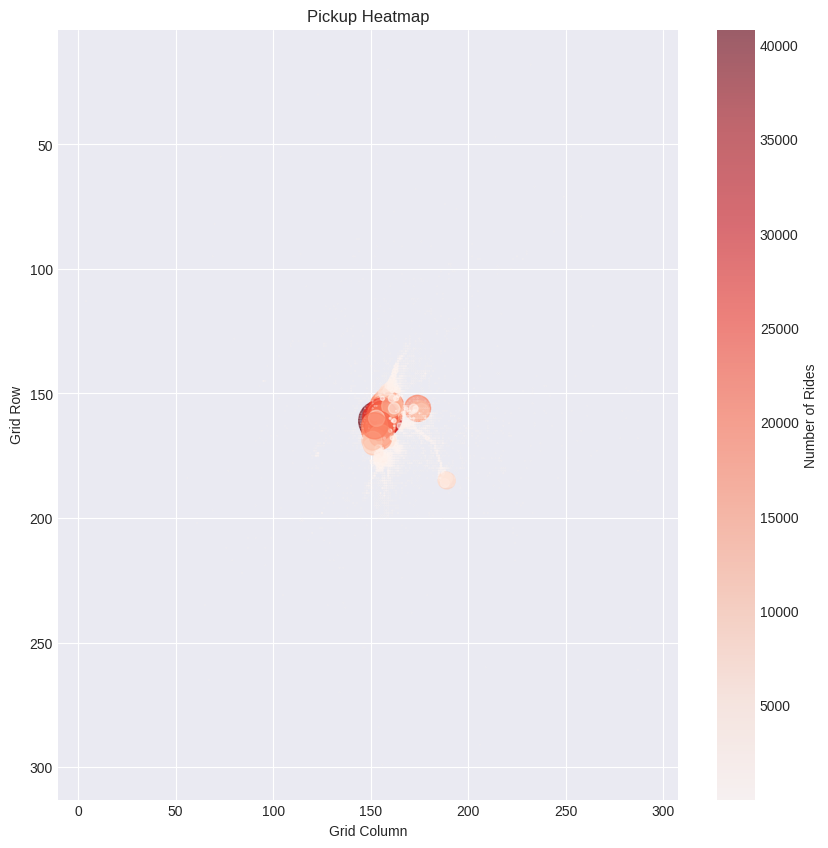

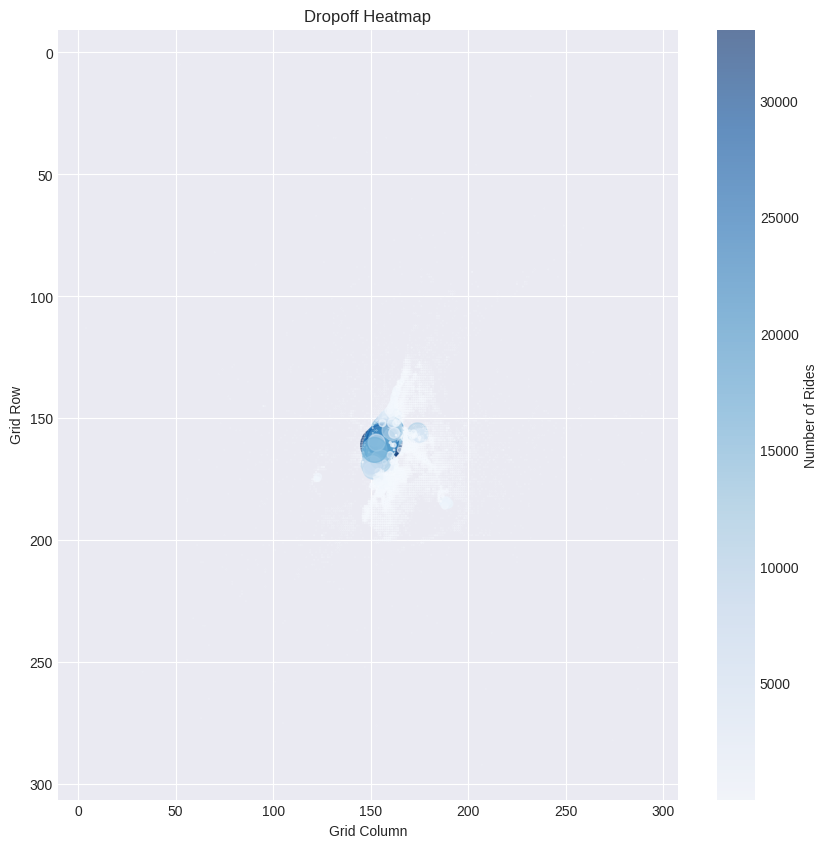

In [118]:
#Heatmap pickup
pickup_pdf = pickup_counts.toPandas()

pickup_pdf.rename(columns={
    "pickup_grid.row": "row",
    "pickup_grid.col": "col"
}, inplace=True)

plt.figure(figsize=(10,10))
plt.scatter(
    pickup_pdf['col'],
    pickup_pdf['row'],
    s=pickup_pdf['pickup_count'] / 50,
    c=pickup_pdf['pickup_count'],
    cmap='Reds',
    alpha=0.6
)
plt.gca().invert_yaxis()
plt.title("Pickup Heatmap")
plt.xlabel("Grid Column")
plt.ylabel("Grid Row")
plt.colorbar(label="Number of Rides")
plt.show()

#Heatmap dropoff
dropoff_pdf = dropoff_counts.toPandas()

dropoff_pdf.rename(columns={
    "dropoff_grid.row": "row",
    "dropoff_grid.col": "col"
}, inplace=True)

plt.figure(figsize=(10,10))
plt.scatter(
    dropoff_pdf['col'],
    dropoff_pdf['row'],
    s=dropoff_pdf['dropoff_count'] / 50,
    c=dropoff_pdf['dropoff_count'],
    cmap='Blues',
    alpha=0.6
)
plt.gca().invert_yaxis()
plt.title("Dropoff Heatmap")
plt.xlabel("Grid Column")
plt.ylabel("Grid Row")
plt.colorbar(label="Number of Rides")
plt.show()

The patterns observed in the heatmaps are fully consistent with the tabular results. There is a clearly defined and highly concentrated cluster centered around the grid coordinates approximately at (160, 150). The surrounding cells also display elevated values, indicating intense mobility within a compact and central area of the city.

It is also evident that the pickup hotspots closely mirror the dropoff hotspots. This alignment confirms that the most frequent pickup locations are likewise the most frequent dropoff locations, suggesting that these grid cells correspond to highly active zones—likely situated in the central region of New York City.

## Most Frequent Routes Heatmap

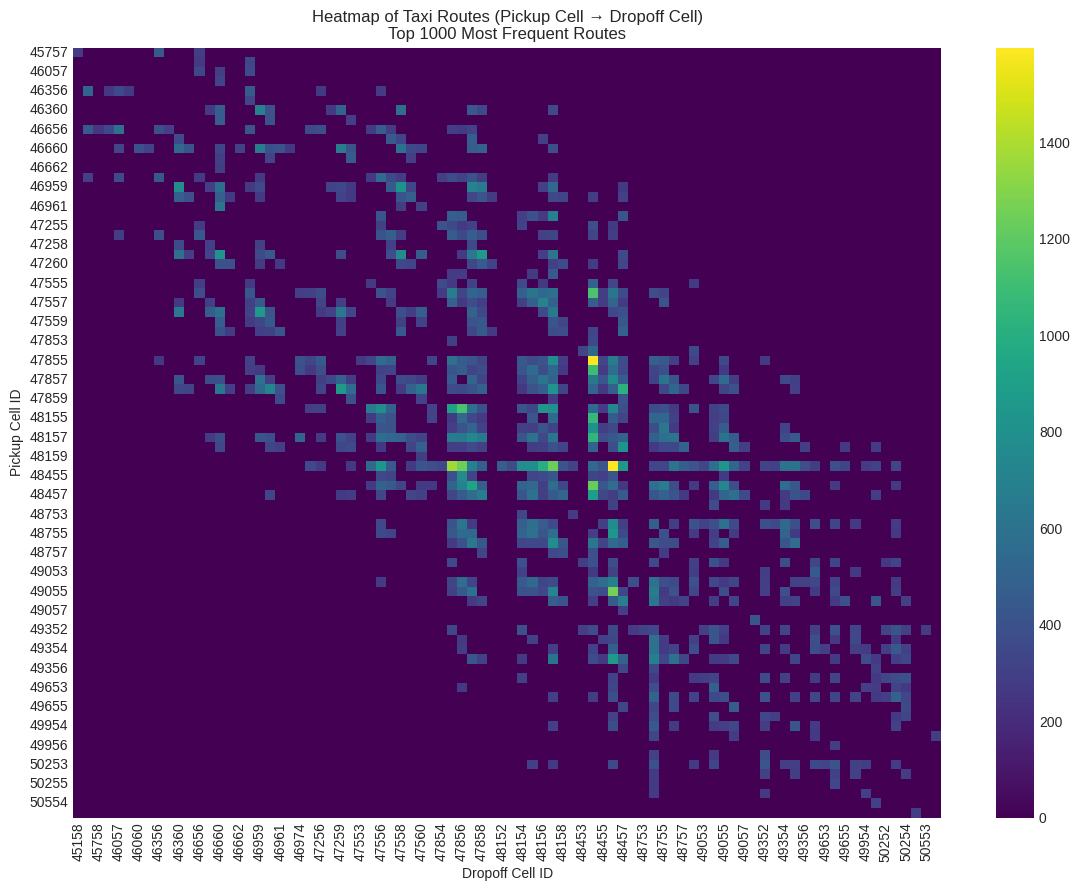

In [119]:
from pyspark.sql import functions as F
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Compute frequency of all routes (pickup cell -> dropoff cell)
routes_all = (
    data.groupBy(
        F.col("pickup_grid.row").alias("pickup_row"),
        F.col("pickup_grid.col").alias("pickup_col"),
        F.col("dropoff_grid.row").alias("dropoff_row"),
        F.col("dropoff_grid.col").alias("dropoff_col")
    )
    .count()
)

#Keep only the most frequent routes (to keep the heatmap readable)
top_routes = routes_all.orderBy(F.col("count").desc()).limit(1000)

#Create numeric IDs for pickup and dropoff cells (flattened grid index)
top_routes = (
    top_routes
    .withColumn("pickup_id", F.col("pickup_row") * F.lit(300) + F.col("pickup_col"))
    .withColumn("dropoff_id", F.col("dropoff_row") * F.lit(300) + F.col("dropoff_col"))
)

#Convert to pandas for plotting
pdf_routes = top_routes.select("pickup_id", "dropoff_id", "count").toPandas()

#Pivot table: rows = pickup_id, columns = dropoff_id, values = number of trips
pivot_routes = pdf_routes.pivot_table(
    values="count",
    index="pickup_id",
    columns="dropoff_id",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(14,10))
sns.heatmap(pivot_routes, cmap="viridis")
plt.title("Heatmap of Taxi Routes (Pickup Cell → Dropoff Cell)\nTop 1000 Most Frequent Routes")
plt.xlabel("Dropoff Cell ID")
plt.ylabel("Pickup Cell ID")
plt.show()

The route heatmap, built from the 1000 most frequent origin–destination pairs, shows that most high-intensity flows occur between a relatively small subset of grid cells. This reinforces the idea that a dense core of the city concentrates not only the highest number of pickups and dropoffs, but also the majority of origin–destination movements, suggesting that many trips occur within or between central, highly active areas.

# Temporal Analysis

## Data Cleaning and Formatting


In [120]:
#Creation of temporal columns
from pyspark.sql.functions import hour, dayofweek, month, year, date_format, when

data = (data
    .withColumn("pickup_hour", hour("pickup_datetime"))
    .withColumn("pickup_dayofweek", dayofweek("pickup_datetime"))
    .withColumn("pickup_month", month("pickup_datetime"))
    .withColumn("pickup_year", year("pickup_datetime"))
    .withColumn("pickup_date", date_format("pickup_datetime", "yyyy-MM-dd"))
    .withColumn("dropoff_hour", hour("dropoff_datetime"))
    .withColumn("dropoff_dayofweek", dayofweek("dropoff_datetime"))
    .withColumn("dropoff_month", month("dropoff_datetime"))
    .withColumn("dropoff_year", year("dropoff_datetime"))
    .withColumn("dropoff_date", date_format("dropoff_datetime", "yyyy-MM-dd"))
)



## Number of rides per hour of the day

In [121]:
data.createOrReplaceTempView("rides")

#Pick up
spark.sql("""
    SELECT pickup_hour, COUNT(*) AS total_rides
    FROM rides
    GROUP BY pickup_hour
    ORDER BY pickup_hour
""").show(24, truncate=False)

#Dropoff
spark.sql("""
    SELECT dropoff_hour, COUNT(*) AS total_rides
    FROM rides
    GROUP BY dropoff_hour
    ORDER BY dropoff_hour
""").show(24, truncate=False)

+-----------+-----------+
|pickup_hour|total_rides|
+-----------+-----------+
|0          |67981      |
|1          |49983      |
|2          |37046      |
|3          |26756      |
|4          |19587      |
|5          |17109      |
|6          |35263      |
|7          |61303      |
|8          |76125      |
|9          |79243      |
|10         |76989      |
|11         |79905      |
|12         |83534      |
|13         |83169      |
|14         |85210      |
|15         |80999      |
|16         |67990      |
|17         |82605      |
|18         |101435     |
|19         |106821     |
|20         |100946     |
|21         |98950      |
|22         |95978      |
|23         |84921      |
+-----------+-----------+

+------------+-----------+
|dropoff_hour|total_rides|
+------------+-----------+
|0           |71818      |
|1           |53386      |
|2           |39307      |
|3           |28298      |
|4           |21183      |
|5           |16310      |
|6           |31394      |
|

It is possible to observe that taxi requests follow a temporal pattern for both pickups and dropoffs, and this pattern is quite similar in both cases.

Taxis are most frequently requested for pickups and dropoffs in the late afternoon and early evening, specifically between 18h and 20h, where the total number of rides exceeds 100,000 in both cases, with a maximum of 108,900 rides for pickups and 111,149 rides for dropoffs, both recorded at 19h.

It is also noticeable that demand is lower during the early morning hours, particularly between 2h and 5h, with 17,510–37,832 rides for pickups and 16,695–40,136 rides for dropoffs, with the minimum in both cases occurring at 5h.
During the remaining hours of the day, such as from 8h to 5h and from 10h to 11h, a moderate number of rides is observed. For pickups, this ranges between 77,684 and 98,003 rides, while for dropoffs it ranges between 72,448 and 98,962 rides.

## Number of rides per day of the week

In [122]:
#Pick up
spark.sql("""
    SELECT pickup_dayofweek, COUNT(*) AS total_rides
    FROM rides
    GROUP BY pickup_dayofweek
    ORDER BY pickup_dayofweek
""").show()

#Dropoff
spark.sql("""
    SELECT dropoff_dayofweek, COUNT(*) AS total_rides
    FROM rides
    GROUP BY dropoff_dayofweek
    ORDER BY dropoff_dayofweek
""").show()

+----------------+-----------+
|pickup_dayofweek|total_rides|
+----------------+-----------+
|               1|     225172|
|               2|     220383|
|               3|     242720|
|               4|     244974|
|               5|     250983|
|               6|     258412|
|               7|     257204|
+----------------+-----------+

+-----------------+-----------+
|dropoff_dayofweek|total_rides|
+-----------------+-----------+
|                1|     227179|
|                2|     220229|
|                3|     242451|
|                4|     244735|
|                5|     250364|
|                6|     257967|
|                7|     256923|
+-----------------+-----------+



The tables show that the number of rides per weekday is also quite similar for pickups and dropoffs, as expected.

The data indicate that the days with the fewest rides are Monday and Tuesday, with a minimum of 220,383 rides for pickups and 220,229 rides for dropoffs, with this minimum occurring on Tuesday in both cases.
From Wednesday onwards, these numbers increase, and between Wednesday and Friday, they remain approximately between 240,000 and 250,000 rides for both scenarios. The highest number of rides occurs on Saturday, with 258,412 rides for pickups and 257,967 rides for dropoffs, and these high values are maintained throughout Sunday.

These figures suggest a typical pattern: stable ride demand during weekdays, followed by a significant increase towards the end of the week, particularly over the weekend.

## Number of rides per month

In [123]:
#Pick up
spark.sql("""
    SELECT pickup_month, COUNT(*) AS total_rides
    FROM rides
    GROUP BY pickup_month
    ORDER BY pickup_month
""").show()

#Dropoff
spark.sql("""
    SELECT dropoff_month, COUNT(*) AS total_rides
    FROM rides
    GROUP BY dropoff_month
    ORDER BY dropoff_month
""").show()

+------------+-----------+
|pickup_month|total_rides|
+------------+-----------+
|           1|     144897|
|           2|     136742|
|           3|     155002|
|           4|     148004|
|           5|     144822|
|           6|     141721|
|           7|     136591|
|           8|     125336|
|           9|     139791|
|          10|     147780|
|          11|     141214|
|          12|     137948|
+------------+-----------+

+-------------+-----------+
|dropoff_month|total_rides|
+-------------+-----------+
|            1|     144867|
|            2|     136745|
|            3|     155030|
|            4|     147987|
|            5|     144797|
|            6|     141753|
|            7|     136568|
|            8|     125338|
|            9|     139810|
|           10|     147757|
|           11|     141224|
|           12|     137972|
+-------------+-----------+



The distribution of rides per month for pickups and dropoffs remains consistent. In general, the values show moderate variation throughout the year, without extreme peaks, but with some noticeable trends.

The months with the highest number of rides were March (approximately 158,000 rides), followed by May (approximately 153,000 rides) and April (approximately 150,000 rides).

The months with the lowest number of rides were August and July (approximately 120,000–130,000 rides). This sharp decrease may be associated with vacation periods and lower urban activity, resulting in fewer daily trips.

Between October and December, the numbers remain stable (around 140,000 rides), indicating consistency during the holiday season.

# Final Conclusion

**Geographic patterns:**

Heatmaps and grid cell analyses show that both pickup and dropoff locations are concentrated in specific areas, mainly around coordinates (161, 154), (160, 157), (161, 156), and neighboring cells. These locations act as both pickup and dropoff hotspots, suggesting they correspond to highly active central areas, likely with a high density of commercial, cultural, or residential activity. Furthermore, the most frequent routes connect neighboring cells, indicating that many trips occur within a compact central region, reinforcing the existence of a dense urban core.

**Temporal patterns:**

Taxi demand also follows consistent temporal trends. The highest demand occurs in the late afternoon and early evening, between 18:00 and 20:00, peaking at 19:00. The lowest demand occurs during the early morning hours (2:00–5:00), with a minimum at 5:00. Across the week, Mondays and Tuesdays have the fewest rides, while demand increases from Wednesday to Friday, peaking over the weekend. Monthly patterns show the highest ride counts in March, April, and May, and the lowest in July and August, likely due to vacation periods. From October to December, ride counts remain stable, indicating consistent demand during the holiday season.

# **Which times of day are more profitable?**

After conducting a detailed temporal analysis based on the frequency of trips requested for each hour, day, and month, it became relevant to also perform a temporal analysis of the revenue generated by these trips. This step aimed to determine whether there is a relationship between the number of trips and the profitability of those trips, and to identify specific periods that are not only busy but also more profitable. By examining revenue patterns across hours of the day, days of the week, and months of the year, the analysis provides a deeper understanding of how demand and profitability interact, offering valuable insights for optimizing taxi operations and resource allocation.

## Profit per hour

In [124]:
#Pick up
spark.sql("""
    SELECT pickup_hour, AVG(total_amount) AS avg_revenue
    FROM rides
    GROUP BY pickup_hour
    ORDER BY pickup_hour
""").show(24)

#Dropoff
spark.sql("""
    SELECT dropoff_hour, AVG(total_amount) AS avg_revenue
    FROM rides
    GROUP BY dropoff_hour
    ORDER BY dropoff_hour
""").show(24)


+-----------+------------------+
|pickup_hour|       avg_revenue|
+-----------+------------------+
|          0|15.323785469469023|
|          1|14.980955925014426|
|          2|14.913527506343383|
|          3|15.315324786963625|
|          4| 17.33925511819054|
|          5|19.709063066222452|
|          6|15.163475881235401|
|          7|13.994384124757005|
|          8|14.067278423644927|
|          9|14.000705929861185|
|         10|13.991950278610828|
|         11|14.031691884111991|
|         12|14.160701630473705|
|         13| 14.71000889754587|
|         14|15.144301842506906|
|         15|15.189049741354781|
|         16|15.813526548021322|
|         17|15.403384783003581|
|         18|14.628019618475282|
|         19|14.180975089168337|
|         20|14.128960434291882|
|         21|14.551949873674067|
|         22|14.901653503928438|
|         23|15.263860882467355|
+-----------+------------------+

+------------+------------------+
|dropoff_hour|       avg_revenue|
+------

The average revenue per hour varies significantly throughout the day; however, the data for pickups and dropoffs remain consistent. Three main patterns can be observed:

Higher revenue during the early morning hours, specifically between 0h and 5h, with earnings ranging from 15–19. The maximum occurs at 5h, with 19.78 for pickups and 18.86 for dropoffs. This can likely be explained by a lower availability of drivers and higher demand at airports.

Lowest revenue during the morning and early afternoon, between 7h and 13h, with earnings around 13–14. The minimum is observed at 10h for pickups (14.018) and 7h for dropoffs (13.454), which likely reflects shorter trips during these hours.

Slight increase in revenue between 14h and 22/23h, with earnings approximately 14–15. This is expected, as these hours generally correspond to higher city traffic and increased post-work travel.

## Profit per day of the week

In [125]:
#Pick up
spark.sql("""
    SELECT pickup_dayofweek, AVG(total_amount) AS avg_revenue
    FROM rides
    GROUP BY pickup_dayofweek
    ORDER BY pickup_dayofweek
""").show()

#Dropoff
spark.sql("""
    SELECT dropoff_dayofweek, AVG(total_amount) AS avg_revenue
    FROM rides
    GROUP BY dropoff_dayofweek
    ORDER BY dropoff_dayofweek
""").show()

+----------------+------------------+
|pickup_dayofweek|       avg_revenue|
+----------------+------------------+
|               1|14.862758158209836|
|               2|14.865474469448177|
|               3|14.665710407055347|
|               4|14.869741237847553|
|               5|15.075926656389344|
|               6| 14.89362874015342|
|               7|14.032493701499128|
+----------------+------------------+

+-----------------+------------------+
|dropoff_dayofweek|       avg_revenue|
+-----------------+------------------+
|                1|14.875007505096967|
|                2|14.863282855574893|
|                3| 14.66715039327727|
|                4|  14.8623384885712|
|                5|15.060113554666634|
|                6|14.903471025365771|
|                7|14.034221692882237|
+-----------------+------------------+



The average revenue varies little throughout the week, remaining consistently between 14.0 and 15.1. The values are very similar for pickups and dropoffs, further reinforcing the consistency of the data.

Nonetheless, some patterns can be observed. Friday records the highest average revenue of the week (15.11 for pickups and 15.10 for dropoffs), while Sunday has the lowest average revenue (14.0 in both cases).

The remaining weekdays show a more stable trend, with earnings ranging between 14.7 and 14.9.

## Profit per month

In [126]:
#Pick up
spark.sql("""
    SELECT pickup_month, AVG(total_amount) AS avg_revenue
    FROM rides
    GROUP BY pickup_month
    ORDER BY pickup_month
""").show()

#Dropoff
spark.sql("""
    SELECT dropoff_month, AVG(total_amount) AS avg_revenue
    FROM rides
    GROUP BY dropoff_month
    ORDER BY dropoff_month
""").show()


+------------+------------------+
|pickup_month|       avg_revenue|
+------------+------------------+
|           1|13.889772804131322|
|           2|13.977187696539204|
|           3|14.341333273120432|
|           4|14.630807275480327|
|           5|14.974641490934918|
|           6| 15.06611532518215|
|           7|14.754081381643974|
|           8|14.987614252889166|
|           9|15.207649133350387|
|          10|15.190934361890658|
|          11|14.907669777785367|
|          12|15.085754487199466|
+------------+------------------+

+-------------+------------------+
|dropoff_month|       avg_revenue|
+-------------+------------------+
|            1|13.888449681433428|
|            2|13.976699477130161|
|            3|14.342086950914094|
|            4| 14.62979011670072|
|            5| 14.97456798138204|
|            6| 15.06677615288663|
|            7|14.752360216157022|
|            8|14.990481657598792|
|            9|15.205468421430409|
|           10|15.190804361216069|


The average monthly revenue varies between 13.9 and 15.25, indicating moderate fluctuation. Revenue tends to increase over the year, reaching its highest values between May and December. Pickups and dropoffs show nearly identical numbers, further reinforcing the consistency of the data.

The months with the highest average revenue are September (15.25), October (15.22), and December (15.12). The higher revenue in December may be associated with the holiday season.
The months with the lowest average revenue are January (13.93), February (14.0), and March (14.39).
The remaining months show intermediate values, ranging between 14.6 and 14.9.

## Final Conclusion


In summary, the most profitable times of day are during the early morning hours (0:00–5:00), even though the highest demand occurs later in the day (18:00–20:00). Revenue is moderately higher in the late afternoon and evening compared to the morning and early afternoon. On a weekly scale, Fridays are the most profitable, while Sundays are the least. Across the year, the most profitable months are September, October, and December. These insights indicate that taxi profitability depends not only on ride frequency but also on factors such as trip length, traffic conditions, and driver availability, highlighting opportunities for optimizing operations and resource allocation.

# **Temporal Relationship Between Taxi Demand and Revenue**


Taxi demand and revenue in New York City follow related but distinct temporal patterns. Ride requests peak in the late afternoon and early evening (18:00–20:00), with over 100,000 trips, while the lowest demand occurs in the early morning (2:00–5:00), reaching a minimum at 5:00. In contrast, the highest revenue is observed during the early morning hours (0:00–5:00), peaking at 5:00, likely due to longer trips and airport demand, even though the number of rides is lower at this time. Revenue is moderate during late afternoon and evening (14:00–22:00), coinciding with high demand, but still lower than early morning peaks.

Weekly patterns show stable ride counts from Monday to Friday, with higher demand over the weekend, while revenue is highest on Fridays and lowest on Sundays. Monthly trends indicate that ride volume peaks in March, April, and May, with a dip in July and August, whereas revenue peaks between September and December, with the lowest earnings in January to March.

These findings highlight that periods of highest demand do not always correspond to highest profitability. Early morning rides, though fewer, are more lucrative per trip, while late afternoon and evening hours see the largest number of trips but moderate revenue per ride. Understanding this distinction can help optimize taxi operations, driver allocation, and strategic planning for revenue maximization.

#